In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [18]:
df = pd.read_csv("students.csv")

# remove extra spaces from column names
df.columns = df.columns.str.strip()

# check columns
print(df.columns)

df.head()

Index(['name', 'math', 'science', 'english', 'history', 'pe', 'attendance_pct',
       'study_hours_per_day', 'passed'],
      dtype='str')


,name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
0,Alice,88,92,76,80,95,92,4.5,1
1,Bob,42,55,48,50,60,65,1.2,0
2,Charlie,75,70,80,68,88,85,3.0,1
3,Diana,95,98,91,89,97,98,6.0,1
4,Eve,38,42,50,45,55,58,0.8,0


In [19]:
print(df.shape)
print(df.dtypes)
df.describe()

(15, 9)
name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object


,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,65.000000,66.733333,66.200000,63.400000,74.800000,75.800000,2.893333,0.600000
std,20.060622,18.967893,17.773174,16.936014,16.657045,14.722189,1.658944,0.507093
min,30.000000,35.000000,40.000000,28.000000,45.000000,50.000000,0.500000,0.000000
25%,51.500000,53.500000,49.000000,53.500000,61.000000,63.500000,1.650000,0.000000
50%,65.000000,65.000000,70.000000,62.000000,75.000000,78.000000,2.800000,1.000000
75%,80.000000,77.000000,81.000000,73.500000,89.000000,86.500000,3.900000,1.000000
max,95.000000,98.000000,91.000000,92.000000,97.000000,98.000000,6.000000,1.000000


In [23]:
df['passed'].value_counts()

passed
1    9
0    6
Name: count, dtype: int64

In [24]:
subject_cols = ['math', 'science', 'english', 'history', 'pe']

df[df['passed']==1][subject_cols].mean()
df[df['passed']==0][subject_cols].mean()

math       45.166667
science    49.000000
english    46.833333
history    48.333333
pe         58.000000
dtype: float64

In [25]:
df['avg_score'] = df[subject_cols].mean(axis=1)
df.loc[df['avg_score'].idxmax()]

name                   Diana
math                      95
science                   98
english                   91
history                   89
pe                        97
attendance_pct            98
study_hours_per_day      6.0
passed                     1
avg_score               94.0
Name: 3, dtype: object

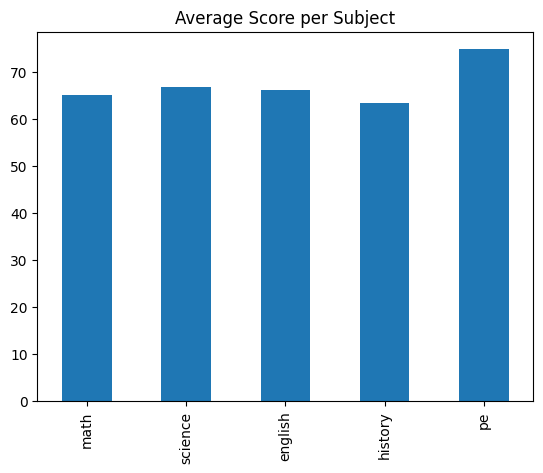

In [26]:
df[subject_cols].mean().plot(kind='bar')
plt.title("Average Score per Subject")
plt.show()

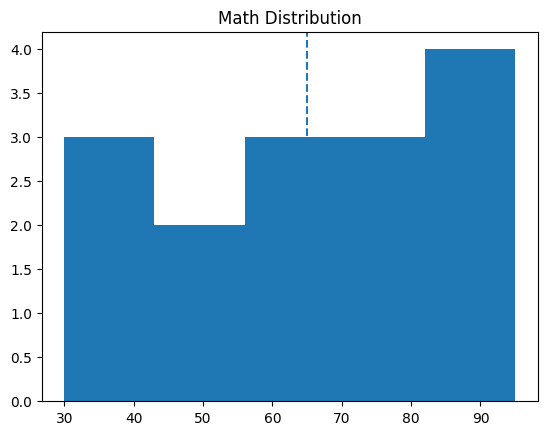

In [27]:
plt.hist(df['math'], bins=5)
plt.axvline(df['math'].mean(), linestyle='dashed')
plt.title("Math Distribution")
plt.show()

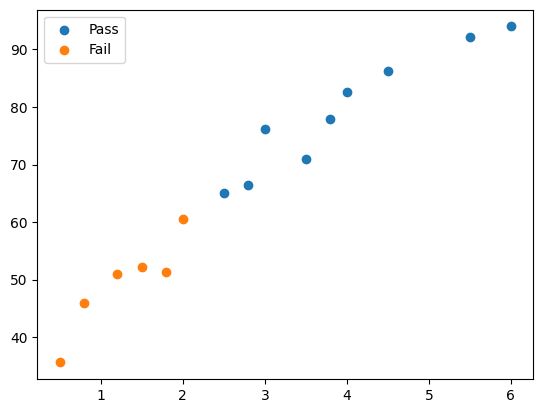

In [28]:
pass_df = df[df['passed']==1]
fail_df = df[df['passed']==0]

plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label='Pass')
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label='Fail')

plt.legend()
plt.show()

C:\Users\LW\AppData\Local\Temp\ipykernel_21568\437558616.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([


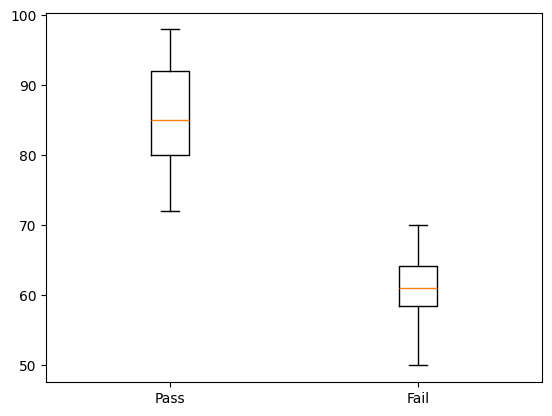

In [29]:
plt.boxplot([
    pass_df['attendance_pct'],
    fail_df['attendance_pct']
], labels=['Pass','Fail'])

plt.show()

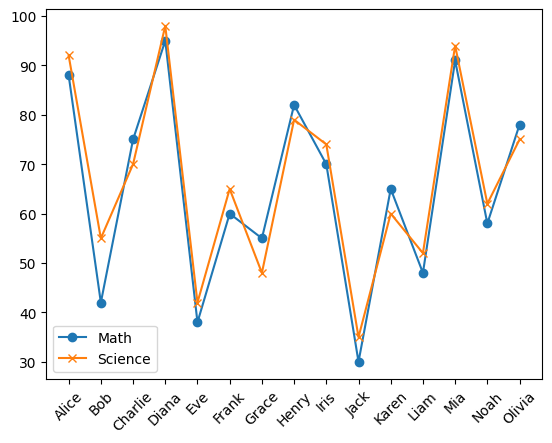

In [30]:
plt.plot(df['name'], df['math'], marker='o', label='Math')
plt.plot(df['name'], df['science'], marker='x', label='Science')

plt.xticks(rotation=45)
plt.legend()
plt.show()

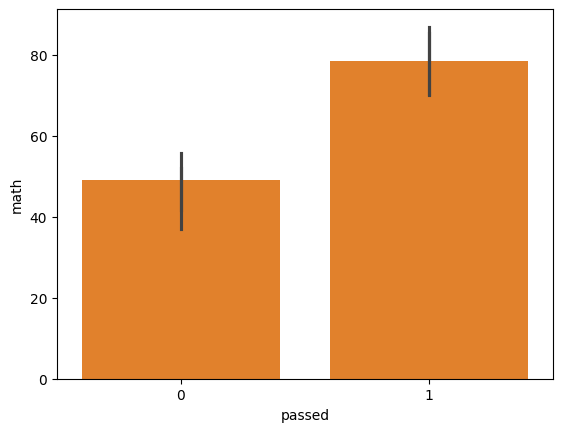

In [31]:
sns.barplot(data=df, x='passed', y='math')
sns.barplot(data=df, x='passed', y='science')
plt.show()

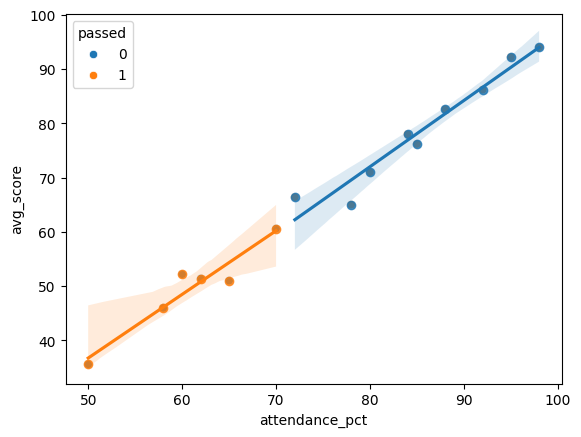

In [32]:
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score')
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score')

plt.show()

In [41]:
X = df[['math','science','english','history','pe','attendance_pct','study_hours_per_day']]
y = df['passed']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

model.score(X_train_scaled, y_train)

1.0

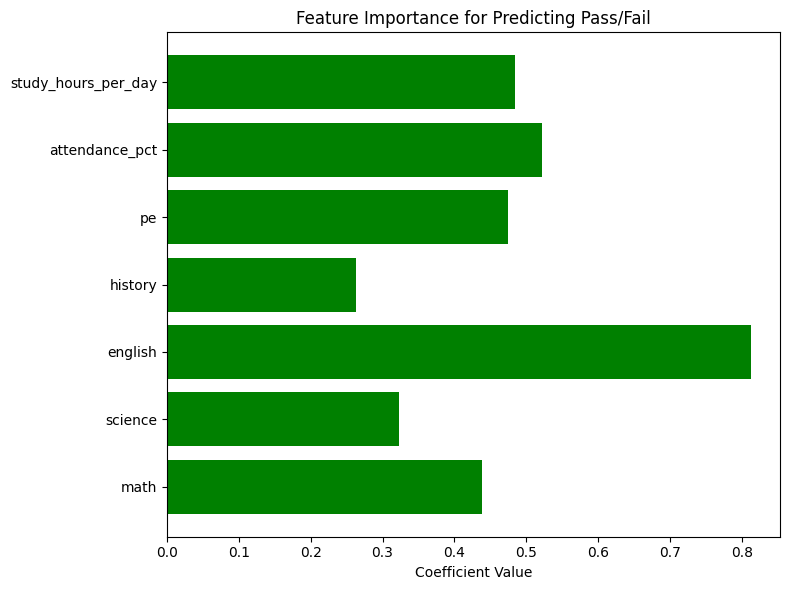

In [42]:
# Step 4 — Feature Importance

# Get feature names and coefficients
feature_names = X.columns
coefficients = model.coef_[0]

# Create a horizontal bar chart
colors = ['green' if c > 0 else 'red' for c in coefficients]

plt.figure(figsize=(8,6))
plt.barh(feature_names, coefficients, color=colors)
plt.xlabel("Coefficient Value")
plt.title("Feature Importance for Predicting Pass/Fail")
plt.tight_layout()
plt.savefig("feature_importance.png")   # <- this saves the PNG
plt.show()

In [37]:
y_pred = model.predict(X_test_scaled)
model.score(X_test_scaled, y_test)

1.0

In [38]:
names = df.loc[X_test.index, 'name']

for i, name in enumerate(names):
    print(name, y_test.iloc[i], y_pred[i])

Jack 0 0
Liam 0 0
Alice 1 1


In [39]:
coeffs = model.coef_[0]
features = X.columns

list(zip(features, coeffs))

[('math', np.float64(0.43794393086873595)),
 ('science', np.float64(0.3230097624690249)),
 ('english', np.float64(0.8125127982724648)),
 ('history', np.float64(0.26292892629062437)),
 ('pe', np.float64(0.47497406284967797)),
 ('attendance_pct', np.float64(0.521876340433209)),
 ('study_hours_per_day', np.float64(0.4844326627100155))]

In [40]:
new_student = [[75,70,68,65,80,82,3.2]]

new_scaled = scaler.transform(new_student)

model.predict(new_scaled)
model.predict_proba(new_scaled)

C:\Users\LW\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.09203526, 0.90796474]])